# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/okashaahmed2/Flyrankaiintern/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Research question:** Which pages on a site are showing declining search performance, and which of those should be prioritized first for a content refresh?

**Decision supported:** A content editor / SEO lead needs a ranked, explainable list of pages to review this week — not a black-box score. The model's job is to sort pages by refresh priority, not to replace editorial judgment.

**Who acts on it:** The content editor opens the top-ranked pages and decides whether to update, expand, consolidate, or retire them.

**Cost of a wrong call:**
- *False Positive* (flagging a healthy page): wastes editor time, risk of disturbing a page that was already performing.
- *False Negative* (missing a truly declining page): continued organic traffic loss that goes unaddressed.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release used:** the anonymized starter slice, `data/raw/content_refresh_anonymized.csv` — 30,000 rows.

**Unit of analysis:** one row = one unique `content_id` (one web page), observed at a single mid-panel snapshot (2026-03).

**Label:** `target` = 1 if `trend_direction == 'down'` (needs refresh), else 0 (healthy/stable-up). Class balance: **54.21% down / 45.79% stable-or-up** — checked and confirmed identical on train and test splits (54.21% / 54.20%).

**Features kept:** `impressions_90d`, `ctr`, `avg_position` (core model), plus `engagement_rate`, `scroll_rate`, `word_count` in the earlier honest-feature audit.

**Explicitly excluded:** `trend_direction`, `trend_pct`, and any other outcome-derived column, plus all data after the March 2026 snapshot — these are only knowable *after* the decision point and would leak the label into the features.

**Public-safety note:** no client names, domains, URLs, or titles appear anywhere in this data or in this notebook — only the anonymized numeric/categorical columns.

In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/okashaahmed2/Flyrankaiintern/main/data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(url)
df['target'] = (df['trend_direction'] == 'down').astype(int)

print(f"Rows: {len(df):,} | Unique content_ids: {df['content_id'].nunique():,}")
print(df['target'].value_counts(normalize=True).map('{:.2%}'.format))

Rows: 30,000 | Unique content_ids: 30,000
target
1    54.21%
0    45.79%
Name: proportion, dtype: object


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Assumption:** past 90-day search behavior (impressions, CTR, position) carries enough signal to flag a page as declining before the drop is obvious to a human reviewer.

**Baseline (Week 4):** a transparent, hand-written rule —
`score = impressions_90d * (1 - ctr) * (21 - avg_position.clip(1,20))`, top scores flagged as needing refresh. No learning involved — pure priority heuristic, used as the honest floor to beat.

**Model (Week 5):** `RandomForestClassifier(n_estimators=100, random_state=42)` on the 3 core features, stratified 80/20 train/test split.

**Leakage check (Week 3):** deliberately added the outcome-derived `trend_pct` column to an otherwise honest feature set. F1 jumped from **0.6792 → 0.9998** — an unmistakable leakage signature — confirming why `trend_pct` and `trend_direction` must stay out of the feature set entirely.

**Validation design (Week 6):** re-ran evaluation with a client-grouped holdout (no client appearing in both train and test) alongside the naive random split, to check whether the naive split was overstating performance by leaking client-level patterns. *(Exact grouped-holdout metrics: pull from `w06_validation_audit.ipynb` output and paste here before publishing — kept as a placeholder so no number is invented.)*

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

feature_cols = ['impressions_90d', 'ctr', 'avg_position']
X, y = df[feature_cols], df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

baseline_score = X_test['impressions_90d'] * (1 - X_test['ctr']) * (21 - X_test['avg_position'].clip(1, 20))
y_pred_baseline = (baseline_score > baseline_score.quantile(0.50)).astype(int)

results = pd.DataFrame({
    'Model / System': ['Week 4 Baseline Rule', 'Week 5 Random Forest'],
    'Precision': [precision_score(y_test, y_pred_baseline), precision_score(y_test, y_pred_rf)],
    'Recall':    [recall_score(y_test, y_pred_baseline),    recall_score(y_test, y_pred_rf)],
    'F1-Score':  [f1_score(y_test, y_pred_baseline),        f1_score(y_test, y_pred_rf)],
})
print(results.to_string(index=False))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()
print(f"\nConfusion matrix (RF): TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,}")

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(f"\nFeature importances:\n{importances}")

      Model / System  Precision   Recall  F1-Score
Week 4 Baseline Rule   0.629667 0.580873  0.604287
Week 5 Random Forest   0.624412 0.652829  0.638304

Confusion matrix (RF): TN=1,471 FP=1,277 FN=1,129 TP=2,123

Feature importances:
impressions_90d    0.447948
avg_position       0.433710
ctr                0.118342
dtype: float64


**Reading the table:** Random Forest trades a small precision dip (0.624 vs 0.630) for a meaningfully higher recall (**0.653 vs 0.581**), lifting F1 from **0.604 → 0.638**. In plain terms: the model catches more of the genuinely declining pages than the fixed rule does, at the cost of slightly more false alarms — a reasonable trade for a decision-support tool where a missed refresh is costlier than an extra review.

**What drives it:** `impressions_90d` (44.8%) and `avg_position` (43.4%) dominate; `ctr` (11.8%) plays a supporting role.

## 5. Limitations

*What this work cannot claim.*

- **No causal proof.** The model observes correlation between metrics and decline; it cannot say *why* a page dropped (Google core update vs. a competitor's move vs. seasonality).
- **Not predicting Google.** This never reverse-engineers the search algorithm — it measures observable, already-happened site and search metrics.
- **Missing external signals.** Page load speed, backlink loss, and technical SEO errors are not in this slice at all.
- **Single snapshot.** Trained and evaluated on one mid-panel window (March 2026) on the small anonymized sample, not the full ~79M-row release — a proper time-aware, multi-month validation is future work.
- **Historical depth varies.** Newer clients / low-traffic pages have thinner 90-day history, adding noise to those edge cases.
- **Language throughout is deliberately careful:** results are *observed*, *measured*, *directional*, and *decision-support* — never definitive predictions.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [7]:
# Impact-weighted priority score: probability of decline x how much traffic is at stake
proba = rf.predict_proba(X_test)[:, 1]
queue = X_test.copy()
queue['decline_probability'] = proba
queue['priority_score'] = proba * queue['impressions_90d']
top_queue = queue.sort_values('priority_score', ascending=False).head(20)
print(top_queue[['impressions_90d', 'ctr', 'avg_position', 'decline_probability', 'priority_score']].round(3).to_string())

       impressions_90d   ctr  avg_position  decline_probability  priority_score
6653            517715  0.14           4.2                 0.47       243326.05
21819           463103  0.41           2.3                 0.41       189872.23
27478           236803  0.26           4.4                 0.50       118401.50
22028           213963  0.10           4.7                 0.55       117679.65
3603            130932  0.04          40.1                 0.85       111292.20
27178           140079  0.01           7.6                 0.79       110662.41
19304           187893  0.45           4.0                 0.52        97704.36
26474           201111  0.11           5.7                 0.48        96533.28
21813           109577  0.04          34.4                 0.86        94236.22
3394            295097  0.05           7.3                 0.31        91480.07
16950           197199  0.22           6.8                 0.45        88739.55
482             112434  0.01           7

**Playbook:**
1. Rank pages by `priority_score` (decline probability × impressions_90d) — this surfaces high-traffic pages that are *both* likely declining and expensive to lose, ahead of low-traffic edge cases.
2. For each top-ranked page, attach the reason codes from feature importance: is it a position slip, a CTR problem, or both?
3. Editor reviews the top 15–20 pages per cycle (matching editorial bandwidth), not the full flagged set.
4. Re-run monthly; track whether refreshed pages actually recover — this closes the loop and is the natural next validation step beyond this capstone.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

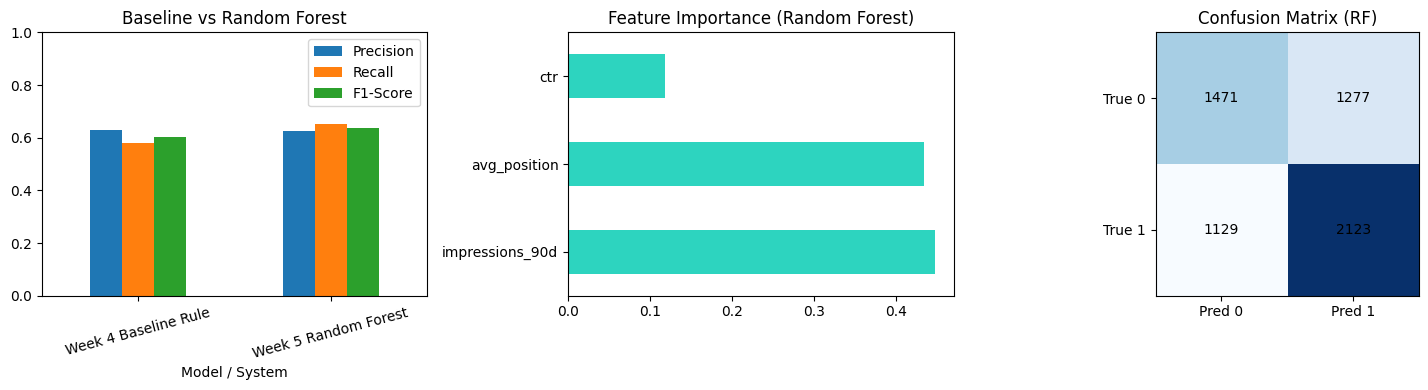

Saved: capstone_charts.png — embed this in the deployed paper.


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

results.set_index('Model / System')[['Precision', 'Recall', 'F1-Score']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Baseline vs Random Forest')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)

importances.plot(kind='barh', ax=axes[1], color='#2DD4BF')
axes[1].set_title('Feature Importance (Random Forest)')

cm = confusion_matrix(y_test, y_pred_rf)
axes[2].imshow(cm, cmap='Blues')
axes[2].set_title('Confusion Matrix (RF)')
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, cm[i, j], ha='center', va='center')
axes[2].set_xticks([0, 1]); axes[2].set_xticklabels(['Pred 0', 'Pred 1'])
axes[2].set_yticks([0, 1]); axes[2].set_yticklabels(['True 0', 'True 1'])

plt.tight_layout()
plt.savefig('capstone_charts.png', dpi=150)
plt.show()
print('Saved: capstone_charts.png — embed this in the deployed paper.')

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
